imports

In [1]:
import os
import sys
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")
mpl.rcParams["animation.embed_limit"] = 100

from cleanroom_cfd.config import SimulationConfig
from cleanroom_cfd.setup import build_room_setup, build_initial_fields
from cleanroom_cfd.data_pipeline import (
    load_timeline_window,
    build_machine_state,
    build_screen_state,
    build_human_entities_for_time,
    update_machine_entities_for_time,
    update_screen_entities_for_time,
)
from cleanroom_cfd.simulation import compute_time_step, compute_tau_field, cfd_step
from cleanroom_cfd.analysis import run_simulation_and_collect_all, save_metric_plots
from cleanroom_cfd.visualization import animate_simulation
from cleanroom_cfd.entities import Entity

experiment settings


In [2]:
cfg = SimulationConfig()

# File paths
csv_path = "../assets/v2_object_timeline_temperature.csv"
real_csv_path = "../assets/thermal_final_data_20260603_172228.csv"
svg_path = "../assets/Feynmann room_inked_good.svg"
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

# Window settings
table_window_minutes = 60
window_start_timestamp = "2025-04-23 14:29:00"

# Simulation settings
save_interval_s = 30.0
cfg.res = 10
cfg.sock_speed = 0.45
cfg.supply_temp = 20.5
cfg.target_time = table_window_minutes * 60
cfg.frames = int(cfg.target_time / save_interval_s)

load timeline data

In [3]:
timeline_data = load_timeline_window(
    csv_path=csv_path,
    table_window_minutes=table_window_minutes,
    window_start_timestamp=window_start_timestamp,
)

print("Window start:", timeline_data["first_ts"])
print("Window end:", timeline_data["end_ts"])
print("Rows in window:", len(timeline_data["df_window"]))
print("Unique timestamps in window:", len(timeline_data["unique_times"]))
print("Labels in window:", sorted(timeline_data["df_window"]["label"].dropna().unique().tolist()))

Window start: 2025-04-23 14:29:00
Window end: 2025-04-23 15:29:00
Rows in window: 501
Unique timestamps in window: 49
Labels in window: ['Light', 'Machine', 'Person', 'Screen', 'Window']


geometry and room setup

In [4]:
room = build_room_setup(cfg, svg_path)

print("Room size:", room["svg_width_m"], "x", room["svg_height_m"])
print("Grid:", room["grid_w"], "x", room["grid_h"])
print("Sock rows:", room["src_y0"], room["src_y1"])

Room size: 15.0 x 12.0
Grid: 150 x 120
Sock rows: 78 82


build static entities and machine state

In [5]:
base_entities_list = [
    Entity("furniture_passthrough", x_m=2.0, y_m=3.8, width_m=8.8, height_m=2.3, id_name="middle_1"),
    Entity("furniture_passthrough", x_m=10.8, y_m=3.0, width_m=1.0, height_m=3.1, id_name="middle_2"),
    Entity("furniture_passthrough", x_m=1.8, y_m=0.0, width_m=3.6, height_m=1.0, id_name="table_1"),
    Entity("furniture_passthrough", x_m=5.7, y_m=0.0, width_m=3.9, height_m=1.0, id_name="table_2"),
    Entity("furniture_passthrough", x_m=9.8, y_m=0.0, width_m=3.8, height_m=1.0, id_name="table_3"),
]

machine_state = build_machine_state(
    df_window=timeline_data["df_window"],
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    machine_radius_m=0.30,
)

persistent_machine_entities = machine_state["persistent_machine_entities"]
machine_entity_map = machine_state["machine_entity_map"]
machine_temp_lookup = machine_state["machine_temp_lookup"]

screen_state = build_screen_state(
    df_window=timeline_data["df_window"],
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    screen_radius_m=0.18,
)

persistent_screen_entities = screen_state["persistent_screen_entities"]
screen_entity_map = screen_state["screen_entity_map"]
screen_temp_lookup = screen_state["screen_temp_lookup"]

persistent_hot_entities = persistent_machine_entities + persistent_screen_entities

print("Persistent machines created:", len(persistent_machine_entities))
print("Persistent screens created:", len(persistent_screen_entities))

Persistent machines created: 5
Persistent screens created: 1


initial fields and tau field

In [6]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

dt = compute_time_step(room["dx"], cfg.sock_speed, cfg.alpha_heat, cfg.nu_eff)

tau_field = compute_tau_field(
    (room["grid_h"], room["grid_w"]),
    room["src_y0"],
    room["src_y1"],
    room["is_obstacle"],
    base_entities_list + persistent_machine_entities,
    cfg.res,
    tau_min=100,
    tau_max=400,
)

substeps_per_frame = int(save_interval_s / dt)

print("dt =", dt)
print("frames =", cfg.frames)
print("substeps_per_frame =", substeps_per_frame)
print("total simulated time represented =", cfg.frames * substeps_per_frame * dt)

dt = 0.06666666666666667
frames = 120
substeps_per_frame = 450
total simulated time represented = 3600.0


TEST

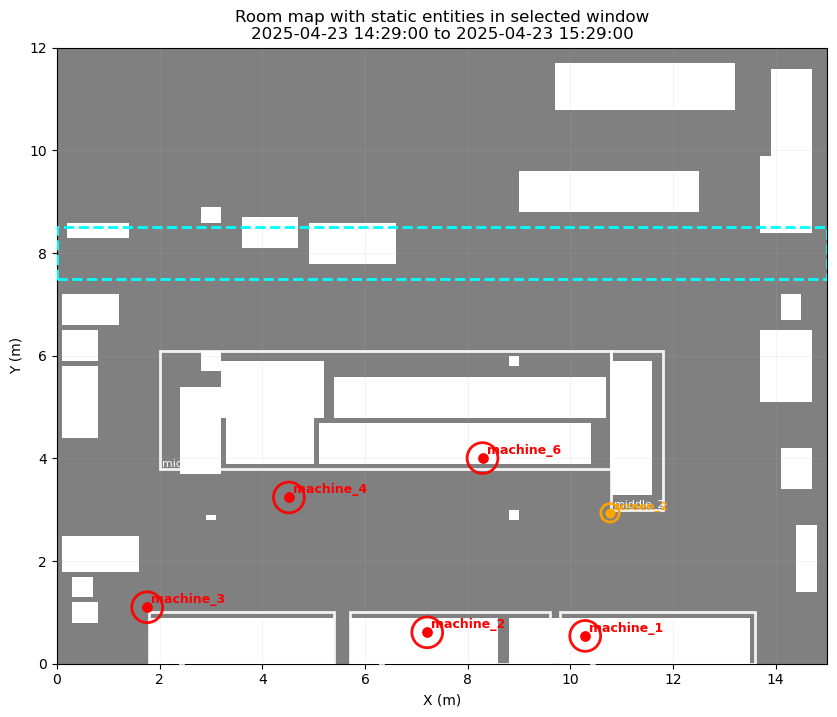

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

plt.figure(figsize=(12, 8))

# Room / obstacles
plt.imshow(
    room["is_obstacle"],
    origin="lower",
    extent=[0, room["svg_width_m"], 0, room["svg_height_m"]],
    cmap="gray",
    alpha=0.5
)

# Base entities (furniture)
for ent in base_entities_list:
    rect = Rectangle(
        (ent.x, ent.y),
        ent.width,
        ent.height,
        fill=False,
        edgecolor="white",
        linewidth=2,
        linestyle="-",
        alpha=0.9,
        zorder=3
    )
    plt.gca().add_patch(rect)
    plt.text(ent.x + 0.05, ent.y + 0.05, ent.id_name, color="white", fontsize=8)

# Machines
for ent in persistent_machine_entities:
    cx = ent.x + ent.width / 2
    cy = ent.y + ent.height / 2

    plt.scatter(cx, cy, s=45, c="red", zorder=6)
    plt.gca().add_patch(Circle(
        (cx, cy),
        radius=getattr(ent, "thermal_radius_m", 0.30),
        fill=False,
        edgecolor="red",
        linewidth=2,
        alpha=0.95,
        zorder=5
    ))
    plt.text(cx + 0.08, cy + 0.08, ent.id_name, color="red", fontsize=9, weight="bold")

# Screens
for ent in persistent_screen_entities:
    cx = ent.x + ent.width / 2
    cy = ent.y + ent.height / 2

    plt.scatter(cx, cy, s=40, c="orange", zorder=6)
    plt.gca().add_patch(Circle(
        (cx, cy),
        radius=getattr(ent, "thermal_radius_m", 0.18),
        fill=False,
        edgecolor="orange",
        linewidth=2,
        alpha=0.95,
        zorder=5
    ))
    plt.text(cx + 0.06, cy + 0.06, ent.id_name, color="orange", fontsize=8, weight="bold")

# Sock band
sock_rect = Rectangle(
    (0, cfg.y_sock_m - cfg.sock_thickness_m),
    room["svg_width_m"],
    2 * cfg.sock_thickness_m,
    fill=False,
    edgecolor="cyan",
    linewidth=2,
    linestyle="--",
    zorder=4
)
plt.gca().add_patch(sock_rect)

plt.xlim(0, room["svg_width_m"])
plt.ylim(0, room["svg_height_m"])
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title(f"Room map with static entities in selected window\n{timeline_data['first_ts']} to {timeline_data['end_ts']}")
plt.grid(alpha=0.15)
plt.show()

step function

In [8]:
sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}

def step_fn(T, tracer, u, v, p):
    update_machine_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        machine_entity_map=machine_entity_map,
        machine_temp_lookup=machine_temp_lookup,
        grace_period_minutes=3,
    )

    update_screen_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        screen_entity_map=screen_entity_map,
        screen_temp_lookup=screen_temp_lookup,
        grace_period_minutes=3,
    )

    human_entities = build_human_entities_for_time(
        sim_time_s=sim_time_state["t"],
        first_ts=timeline_data["first_ts"],
        unique_times=timeline_data["unique_times"],
        rows_by_time=timeline_data["rows_by_time"],
        svg_width_m=room["svg_width_m"],
        svg_height_m=room["svg_height_m"],
    )

    dynamic_entities_state["humans"] = human_entities

    entities_list = base_entities_list + persistent_machine_entities + persistent_screen_entities + human_entities

    out = cfd_step(
        T, tracer, u, v, p,
        dx=room["dx"],
        dt=dt,
        entities_list=entities_list,
        is_obstacle=room["is_obstacle"],
        res=cfg.res,
        src_y0=room["src_y0"],
        src_y1=room["src_y1"],
        hs_x=room["hs_x"],
        hs_y=room["hs_y"],
        bubble_r=cfg.bubble_r,
        alpha_heat=cfg.alpha_heat,
        nu_eff=cfg.nu_eff,
        rho=cfg.rho,
        beta_b=cfg.beta_b,
        g=cfg.g,
        T_ref=cfg.T_ref,
        sock_speed=cfg.sock_speed,
        supply_temp=cfg.supply_temp,
        smoke_diff=cfg.smoke_diff,
        pressure_iters=cfg.pressure_iters,
        max_speed=cfg.max_speed,
        tau_field=tau_field,
    )

    sim_time_state["t"] += dt
    return out

run analysis

In [9]:
# Reset fields
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

# Reset dynamic state
sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}
persistent_hot_entities = persistent_machine_entities + persistent_screen_entities

df_all_metrics, final_state = run_simulation_and_collect_all(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    dt=dt,
    room=room,
    cfg=cfg,
    is_obstacle=room["is_obstacle"],
    persistent_hot_entities=persistent_hot_entities,
    persistent_machine_entities=persistent_machine_entities,
    res=cfg.res,
    dynamic_entities_state=dynamic_entities_state,
    real_start_timestamp=timeline_data["first_ts"],
    machine_exclusion_radius_m=0.60,
    human_exclusion_radius_m=0.30,
    surround_pad_cells=3,
    use_circular_machine_metrics=True,
    default_machine_radius_m=0.30,
    surround_outer_radius_m=0.60,
)
all_metrics_csv = os.path.join(results_dir, "all_metrics.csv")
df_all_metrics.to_csv(all_metrics_csv, index=False)
print("Saved unified metrics to:", all_metrics_csv)
df_all_metrics.head()

Saved unified metrics to: ../results\all_metrics.csv


,room_avg_temp,room_max_temp,room_min_temp,room_std_temp,room_avg_speed,room_max_speed,machine_machine_1_box_temp,machine_machine_1_surround_temp,machine_machine_2_box_temp,machine_machine_2_surround_temp,...,machine_machine_6_surround_temp,ambient_temp_median,ambient_temp_mean,ambient_temp_std,ambient_cell_count,human_count,frame,sim_time_s,sim_time_min,real_datetime
0,20.818677,30.009953,20.644602,0.633704,0.0,0.0,NaN,20.774584,26.880054,20.973807,...,20.979451,20.754544,20.754293,0.034182,12606,5,1,30.0,0.5,2025-04-23 14:29:30
1,20.786366,30.009953,20.607427,0.647507,0.0,0.0,NaN,20.751499,26.880054,21.129136,...,21.038835,20.715976,20.716680,0.054618,12606,5,2,60.0,1.0,2025-04-23 14:30:00
2,20.758523,30.009953,20.579924,0.656538,0.0,0.0,NaN,20.730467,26.880054,21.242591,...,21.062878,20.683257,20.685416,0.065313,12606,5,3,90.0,1.5,2025-04-23 14:30:30
3,20.735073,30.009953,20.559527,0.663415,0.0,0.0,NaN,20.711279,26.880054,21.330026,...,21.074511,20.655500,20.659401,0.072355,12606,5,4,120.0,2.0,2025-04-23 14:31:00
4,20.715407,30.009953,20.544373,0.668942,0.0,0.0,NaN,20.693759,26.880054,21.400637,...,21.080808,20.631948,20.637695,0.077583,12606,5,5,150.0,2.5,2025-04-23 14:31:30


In [10]:
box_cols = [c for c in df_all_metrics.columns if c.endswith("_box_temp")]

plt.figure(figsize=(12, 7))
for col in box_cols:
    plt.plot(df_all_metrics["sim_time_min"], df_all_metrics[col], label=col)

plt.xlabel("Simulation time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Machine hotspot temperatures over time")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

machine_plot_path = os.path.join(results_dir, "machine_box_temperatures.png")
plt.savefig(machine_plot_path, dpi=150)
plt.close()

print("Saved machine plot to:", machine_plot_path)

Saved machine plot to: ../results\machine_box_temperatures.png


In [11]:
plt.figure(figsize=(10, 6))
plt.plot(df_all_metrics["sim_time_min"], df_all_metrics["ambient_temp_median"], label="Sim ambient median")
plt.plot(df_all_metrics["sim_time_min"], df_all_metrics["ambient_temp_mean"], label="Sim ambient mean", alpha=0.8)

plt.xlabel("Simulation time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Simulated ambient temperature over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

sim_ambient_plot_path = os.path.join(results_dir, "simulated_ambient_temperature.png")
plt.savefig(sim_ambient_plot_path, dpi=150)
plt.close()

print("Saved simulated ambient plot to:", sim_ambient_plot_path)

Saved simulated ambient plot to: ../results\simulated_ambient_temperature.png


In [12]:
df_real = pd.read_csv(real_csv_path)
df_real["timestamp"] = pd.to_datetime(df_real["timestamp"])

real_start = timeline_data["first_ts"]
real_end = timeline_data["end_ts"]

df_real_window = df_real[
    (df_real["timestamp"] >= real_start) &
    (df_real["timestamp"] < real_end)
].copy()

df_real_bg = df_real_window[
    df_real_window["class_name"].astype(str).str.strip().str.lower() == "background"
].copy()

df_real_ambient = (
    df_real_bg
    .groupby("timestamp", as_index=False)
    .agg(
        real_ambient_temp_median=("temp_mean_c", "median"),
        real_ambient_temp_mean=("temp_mean_c", "mean"),
        bg_count=("temp_mean_c", "size")
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)
real_ambient_csv = os.path.join(results_dir, "real_ambient.csv")
df_real_ambient.to_csv(real_ambient_csv, index=False)
print("Saved real ambient data to:", real_ambient_csv)
df_real_ambient.head()

Saved real ambient data to: ../results\real_ambient.csv


,timestamp,real_ambient_temp_median,real_ambient_temp_mean,bg_count
0,2025-04-23 14:29:04,22.266619,22.266619,1
1,2025-04-23 14:29:34,22.703668,22.703668,2
2,2025-04-23 14:30:04,21.212416,21.212416,1
3,2025-04-23 14:30:34,21.416397,21.416397,1
4,2025-04-23 14:31:04,21.178009,21.178009,1


In [13]:
df_sim_cmp = df_all_metrics.copy().sort_values("real_datetime").reset_index(drop=True)
df_real_cmp = df_real_ambient.copy().sort_values("timestamp").reset_index(drop=True)

df_compare = pd.merge_asof(
    df_sim_cmp,
    df_real_cmp,
    left_on="real_datetime",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("2min")
)
compare_csv = os.path.join(results_dir, "ambient_comparison.csv")
df_compare.to_csv(compare_csv, index=False)
print("Saved ambient comparison data to:", compare_csv)
plt.figure(figsize=(11, 6))
plt.plot(df_compare["real_datetime"], df_compare["ambient_temp_median"], label="Simulation ambient median", linewidth=2)
plt.plot(df_compare["real_datetime"], df_compare["real_ambient_temp_median"], label="Real background median", linewidth=2)

plt.xlabel("Real time")
plt.ylabel("Temperature (°C)")
plt.title("Ambient temperature comparison: simulation vs real data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()

comparison_plot_path = os.path.join(results_dir, "ambient_temperature_comparison.png")
plt.savefig(comparison_plot_path, dpi=150)
plt.close()

print("Saved comparison plot to:", comparison_plot_path)

Saved ambient comparison data to: ../results\ambient_comparison.csv
Saved comparison plot to: ../results\ambient_temperature_comparison.png


save gif

In [14]:
thermal_grid, sock_tracer, u_vel, v_vel, p = build_initial_fields(
    grid_h=room["grid_h"],
    grid_w=room["grid_w"],
    is_obstacle=room["is_obstacle"],
    T_ref=cfg.T_ref,
    supply_temp=cfg.supply_temp,
    src_y0=room["src_y0"],
    src_y1=room["src_y1"],
)

sim_time_state = {"t": 0.0}
dynamic_entities_state = {"humans": []}

gif_path = os.path.join(results_dir, "simulation.gif")

anim = animate_simulation(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    svg_width_m=room["svg_width_m"],
    svg_height_m=room["svg_height_m"],
    is_obstacle=room["is_obstacle"],
    y_sock_m=cfg.y_sock_m,
    sock_thickness_m=cfg.sock_thickness_m,
    hs_x_m=cfg.hotspot_x_m,
    hs_y_m=cfg.hotspot_y_m,
    v_sock_target=cfg.sock_speed,
    T_supply=cfg.supply_temp,
    dt=dt,
    entities_list=base_entities_list + persistent_machine_entities,
    real_start_timestamp=timeline_data["first_ts"],
    dynamic_entities_state=dynamic_entities_state,
    save_gif_path=gif_path,
    gif_fps=8,
    show_inline=False,
)

print("Saved GIF to:", gif_path)

Saved GIF to: ../results\simulation.gif
